# Example for forward photon dose calculation of a field-based plan.

This example demonstrates how to use the pyRadPlan library to define beam limiting devices
(MLC and jaws), turn them into field shapes, and run a forward photon dose calculation.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_photon_forward.py

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


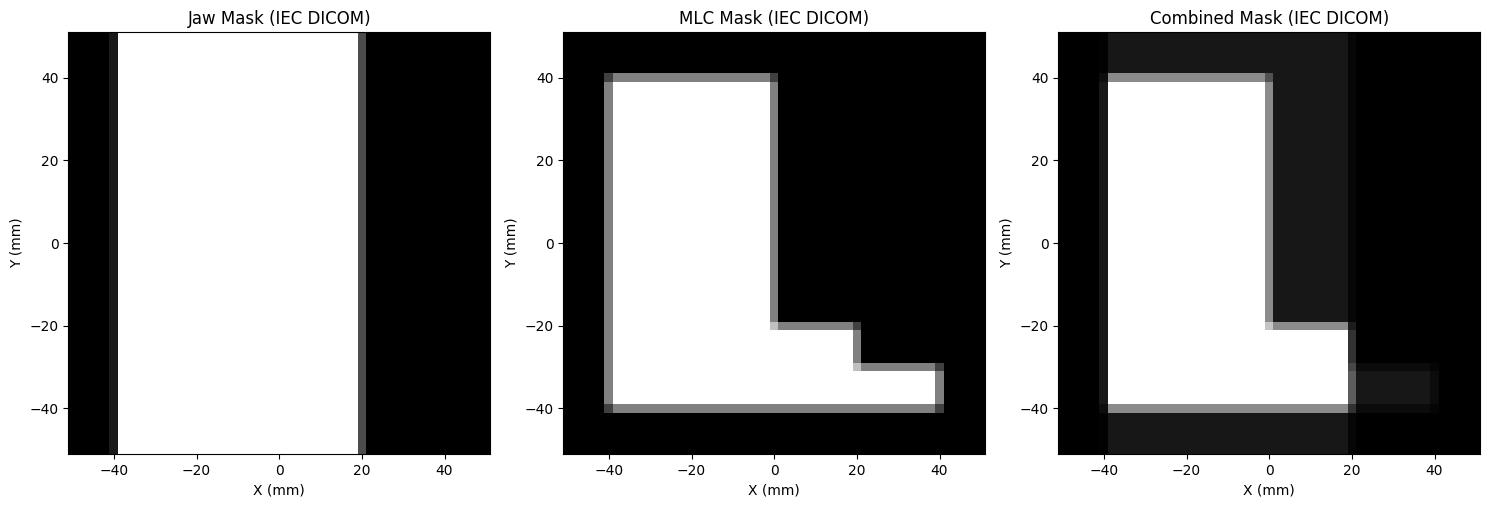

In [1]:
# Import necessary libraries
import logging

import numpy as np

import matplotlib.pyplot as plt

from pyRadPlan import (
    PhotonPlan,
    generate_stf,
    calc_dose_forward,
    plot_slice,
    load_tg119,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.machines import create_bld
from pyRadPlan.stf import FieldShapeAsBLD, FieldShapeComposite

from pyRadPlan.machines.photons._calculate_machine_scale import calculate_machine_scale

logging.basicConfig(level=logging.INFO)


resolution = 1.0

leaf_width = 5
positions = [  # L-form for testing direction
    [0, 0],
    [-20, 20],
    [-20, 10],
    [-20, 0],
    [-20, 0],
    [-20, 0],
    [-20, 0],
    [-20, 0],
    [-20, 0],
    [0, 0],
]
number_of_elements = len(positions)
boundaries = np.arange(
    -int(number_of_elements / 2) * leaf_width, int(number_of_elements / 2) * leaf_width, leaf_width
)

mlc_information = {
    "device_type": "MLC",
    "device_orientation": "X",
    "leaf_position_boundaries": boundaries,
    "leaf_positions": positions,
    "leaf_width": leaf_width,
    "leaf_leakage": 0.1,
}
mlc_x = create_bld(mlc_information)
mask_mlc_x = mlc_x.calculate_transmission_mask(resolution)

jaw_info = {
    "device_type": "JAW",
    "device_orientation": "X",
    "positions": [-20, 10],
    "field_width": 70,
    "leakage": 0.1,
}
jaw_x = create_bld(jaw_info)
jaw_info["field_width"] = mask_mlc_x.shape[0] * resolution
jaw_x_matching_field_width = create_bld(jaw_info)
mask_jaw_x = jaw_x_matching_field_width.calculate_transmission_mask(resolution)

mask = mask_mlc_x * mask_jaw_x

half_size = jaw_info["field_width"]
extent = [-half_size, half_size, -half_size, half_size]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_jaw_x, cmap="gray", origin="lower", extent=extent)
axes[0].set_title("Jaw Mask (IEC DICOM)")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")

axes[1].imshow(mask_mlc_x, cmap="gray", origin="lower", extent=extent)
axes[1].set_title("MLC Mask (IEC DICOM)")
axes[1].set_xlabel("X (mm)")
axes[1].set_ylabel("Y (mm)")

axes[2].imshow(mask, cmap="gray", origin="lower", extent=extent)
axes[2].set_title("Combined Mask (IEC DICOM)")
axes[2].set_xlabel("X (mm)")
axes[2].set_ylabel("Y (mm)")

plt.tight_layout()
plt.show()

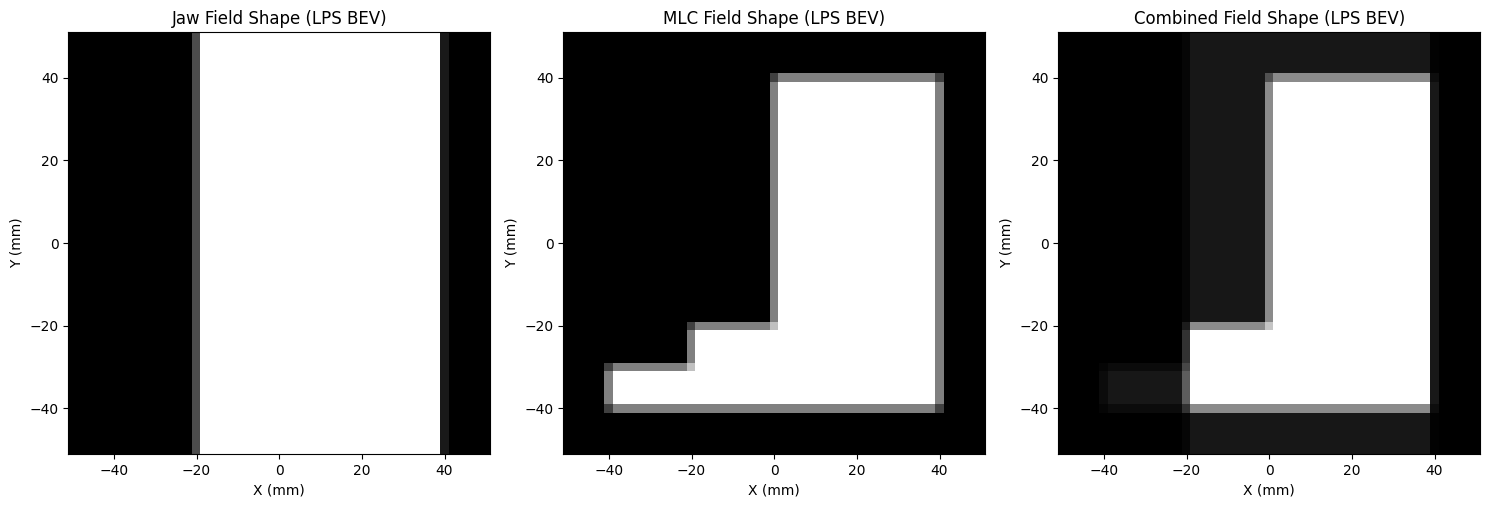

In [2]:
# pyRadPlan internally defines "field shapes" to represent the shape of the beamlets.
mlc_shape = FieldShapeAsBLD(energy=6.0, bld=mlc_x, resolution=resolution)
jaw_shape = FieldShapeAsBLD(energy=6.0, bld=jaw_x_matching_field_width, resolution=resolution)
combined_shape = FieldShapeComposite(energy=6.0, shapes=[mlc_shape, jaw_shape])

# Now plot the field shapes to verify their geometry in LPS BEV coordinates
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(jaw_shape.mask, cmap="gray", origin="lower", extent=extent)
axes[0].set_title("Jaw Field Shape (LPS BEV)")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")

axes[1].imshow(mlc_shape.mask, cmap="gray", origin="lower", extent=extent)
axes[1].set_title("MLC Field Shape (LPS BEV)")
axes[1].set_xlabel("X (mm)")
axes[1].set_ylabel("Y (mm)")

axes[2].imshow(combined_shape.mask, cmap="gray", origin="lower", extent=extent)
axes[2].set_title("Combined Field Shape (LPS BEV)")
axes[2].set_xlabel("X (mm)")
axes[2].set_ylabel("Y (mm)")

plt.tight_layout()
plt.show()

In [3]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a photon therapy plan using the PhotonPencilBeamSVDEngine.

In [4]:
# Create a plan object
pln = PhotonPlan(machine="Generic")
num_of_beams = 1
pln.prop_stf = {
    "gantry_angles": np.linspace(0, 360, num_of_beams, endpoint=False),
    "couch_angles": np.zeros((num_of_beams,)),  # np.array([0, 270]),
    "generator": "photonSingleBixel",
    "field_based": True,
    # "field_shape": np.rot90(mask, k=-1), #TODO: Rotation correct? Should automatically be done in ShapeFromBLD?
    "blds": [mlc_x, jaw_x],
    "resolution": 0.5,
    "energy": 6,
}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Machine Calibration: Calculate the conversion factor between MU and weights
machine = "Generic"
ct_dim = [64, 64, 64]
ct_resolution = [2.0, 2.0, 2.0]
num_of_ct_scen = 1

weights = calculate_machine_scale(machine, ct_dim, ct_resolution, num_of_ct_scen)

# Apply weights to the rays in the stf
for beam in stf.beams:
    for ray in beam.rays:
        for beamlet in ray.beamlets:
            beamlet.weight *= weights

# Forward dose calculation, which directly returns the result on the CT grid
result = calc_dose_forward(ct, cst, stf, pln)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\wahln\AppData\Local\Python\pythoncore-3.13-64\Lib\logging\__init__.py", line 1151, in emit
    msg = self.format(record)
  File "C:\Users\wahln\AppData\Local\Python\pythoncore-3.13-64\Lib\logging\__init__.py", line 999, in format
    return fmt.format(record)
           ~~~~~~~~~~^^^^^^^^
  File "C:\Users\wahln\AppData\Local\Python\pythoncore-3.13-64\Lib\logging\__init__.py", line 712, in format
    record.message = record.getMessage()
                     ~~~~~~~~~~~~~~~~~^^
  File "C:\Users\wahln\AppData\Local\Python\pythoncore-3.13-64\Lib\logging\__init__.py", line 400, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\ipykernel_launcher.py", line 18,

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

INFO:pyRadPlan.dose.engines._base:No weights given. Using weights stored in stf.


INFO:pyRadPlan.dose.engines._base:Forward dose calculation using 'SVD Pencil Beam' Dose Engine...


...

Beam: 100%|██████████| 1/1 [00:00<00:00,  4.10b/s]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.001943 seconds.


INFO:pyRadPlan.dose.engines._base:Forward dose calculation done in 0.68 seconds.


Calculating custom kernel interpolators for ray  0


Visualize the results

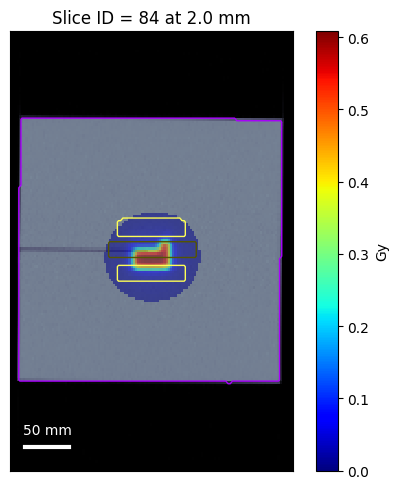

In [5]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[1] / 2))

    # Visualize
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["physical_dose"],
        view_slice=view_slice,
        plane="coronal",
        overlay_unit="Gy",
    )